In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [74]:
df=pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [75]:
#pip install --upgrade openpyxl


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [52]:
#pip install openpyxl

In [77]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [78]:
df.duplicated().sum()

0

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [82]:
df.shape

(918, 12)

<AxesSubplot:>

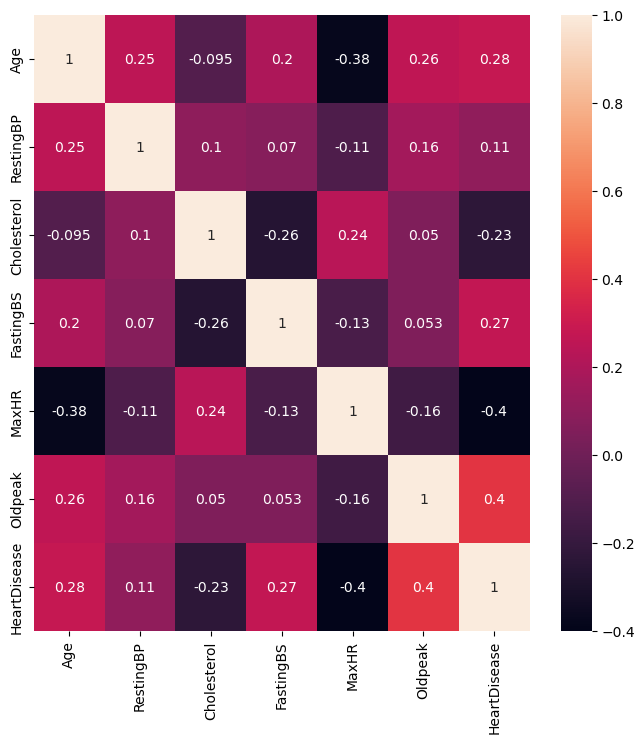

In [83]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True)

In [84]:
#sns.countplot(df.HeartDisease)
#sns.countplot(x='Smoking',hue='HeartDisease',data=df)

In [86]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

# Data preprocessing for balancing


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error,accuracy_score

In [59]:
from sklearn.preprocessing import LabelEncoder

In [60]:
le=LabelEncoder()

In [88]:
list= ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease']
for i in list:
    df[i]=le.fit_transform(df[i])

In [89]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,12,1,1,41,147,0,1,98,0,10,2,0
1,21,0,2,55,40,0,1,82,0,20,1,1
2,9,1,1,31,141,0,2,25,0,10,2,0
3,20,0,0,39,72,0,1,34,1,25,1,1
4,26,1,2,49,53,0,1,48,0,10,2,0


In [90]:
x=df.drop(columns=['HeartDisease'])
y=df['HeartDisease']

In [91]:
x.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
188,22,0,0,22,180,0,1,36,1,20,1
193,17,1,2,36,50,0,1,36,0,10,2
762,12,1,0,14,27,0,0,40,1,30,1
326,17,1,2,14,0,0,1,64,0,9,2
904,28,1,1,22,98,0,1,95,0,10,0
425,32,1,1,55,125,1,2,83,0,15,1
89,27,1,0,41,87,0,1,36,1,15,1
129,14,1,2,22,86,0,1,78,1,25,1
589,46,1,2,41,95,1,1,21,0,10,1
460,29,1,0,40,135,1,2,44,1,29,1


# Split Dataset into Train and Test


In [92]:
from sklearn.model_selection import train_test_split

In [93]:
y.value_counts()

1    508
0    410
Name: HeartDisease, dtype: int64

In [93]:
#!pip install imbalanced-learn


In [94]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [95]:
#xtest.head(50)

In [96]:
ytest.head(50)

668    0
30     1
377    1
535    1
807    0
793    1
363    1
583    0
165    1
483    1
773    0
551    0
768    0
694    0
718    1
312    1
713    0
309    1
846    1
616    0
355    1
39     0
231    0
822    0
603    1
63     1
192    0
481    1
866    0
67     0
72     1
655    1
679    0
139    1
732    1
824    0
174    1
896    0
499    1
70     1
716    1
23     1
541    1
799    0
672    0
826    0
250    1
752    1
350    1
758    0
Name: HeartDisease, dtype: int64

Round 1: Loss=0.7851, Accuracy=0.6087
Round 2: Loss=0.6425, Accuracy=0.6685
Round 3: Loss=0.6584, Accuracy=0.6739
Round 4: Loss=0.6806, Accuracy=0.6413
Round 5: Loss=0.7379, Accuracy=0.6196
Round 6: Loss=0.5835, Accuracy=0.6902
Round 7: Loss=0.5759, Accuracy=0.6902
Round 8: Loss=0.6499, Accuracy=0.6250
Round 9: Loss=0.5929, Accuracy=0.6739
Round 10: Loss=0.5557, Accuracy=0.7011
Round 11: Loss=0.5351, Accuracy=0.7500
Round 12: Loss=0.5287, Accuracy=0.7500
Round 13: Loss=0.5447, Accuracy=0.7283
Round 14: Loss=0.5523, Accuracy=0.7228
Round 15: Loss=0.5810, Accuracy=0.6848
Round 16: Loss=0.5709, Accuracy=0.7011
Round 17: Loss=0.6758, Accuracy=0.6957
Round 18: Loss=0.5331, Accuracy=0.7391
Round 19: Loss=0.5909, Accuracy=0.6848
Round 20: Loss=0.5644, Accuracy=0.7228

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.78      0.70        77
           1       0.81      0.68      0.74       107

    accuracy                           0

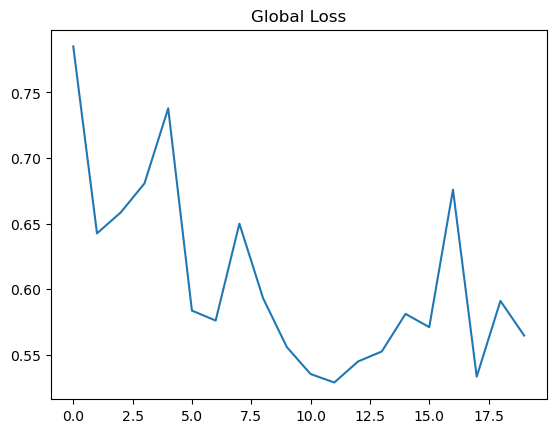

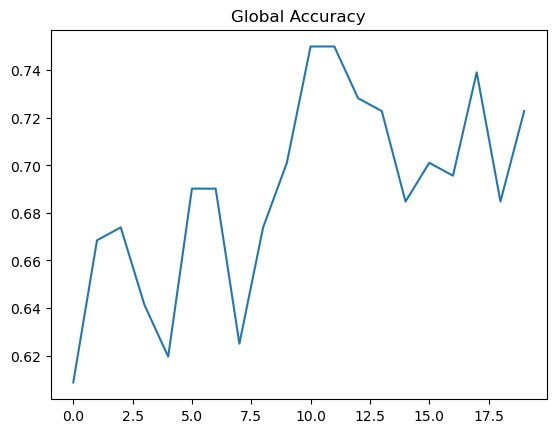

In [97]:
import numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build 1D CNN
# -----------------------------
def build_1dcnn(input_shape, n_classes):
    model = Sequential([
        Conv1D(32, 3, activation='relu', input_shape=input_shape),
        MaxPooling1D(2),
        Conv1D(64, 3, activation='relu'),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_1dcnn(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert DataFrames/Series to NumPy arrays
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for Conv1D
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_1dcnn(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
# Just call the function directly on your DataFrames / Series
global_model = model_fedavg_1dcnn(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [102]:
global_loss_per_round_CNN = [0.7851188778877258, 0.6424854397773743, 0.6584192514419556, 0.6805871725082397, 0.7379006743431091, 0.5835031270980835, 0.5759210586547852, 0.6498751044273376, 0.5928894281387329, 0.5556501746177673, 0.5351000428199768, 0.5286546945571899, 0.5446926951408386, 0.5523067712783813, 0.580998420715332, 0.5709064602851868, 0.6758068799972534, 0.5330930948257446, 0.5909231305122375, 0.5644487738609314]

In [103]:
global_accuracy_per_round_CNN = [0.6086956262588501, 0.66847825050354, 0.6739130616188049, 0.6413043737411499, 0.6195651888847351, 0.6902173757553101, 0.6902173757553101, 0.625, 0.6739130616188049, 0.7010869383811951, 0.75, 0.75, 0.72826087474823, 0.7228260636329651, 0.6847826242446899, 0.7010869383811951, 0.695652186870575, 0.739130437374115, 0.6847826242446899, 0.7228260636329651]

Round 1: Loss=0.6558, Accuracy=0.5815
Round 2: Loss=0.6255, Accuracy=0.6793
Round 3: Loss=0.5995, Accuracy=0.7283
Round 4: Loss=0.5706, Accuracy=0.7283
Round 5: Loss=0.5473, Accuracy=0.7337
Round 6: Loss=0.5358, Accuracy=0.7228
Round 7: Loss=0.5385, Accuracy=0.7500
Round 8: Loss=0.5452, Accuracy=0.7337
Round 9: Loss=0.5171, Accuracy=0.7609
Round 10: Loss=0.5134, Accuracy=0.7663
Round 11: Loss=0.5116, Accuracy=0.7609
Round 12: Loss=0.5194, Accuracy=0.7446
Round 13: Loss=0.4967, Accuracy=0.7717
Round 14: Loss=0.4834, Accuracy=0.7772
Round 15: Loss=0.4783, Accuracy=0.7826
Round 16: Loss=0.4754, Accuracy=0.7717
Round 17: Loss=0.4800, Accuracy=0.7880
Round 18: Loss=0.4806, Accuracy=0.7826
Round 19: Loss=0.4575, Accuracy=0.7935
Round 20: Loss=0.4589, Accuracy=0.7826

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.82      0.76        77
           1       0.85      0.76      0.80       107

    accuracy                           0

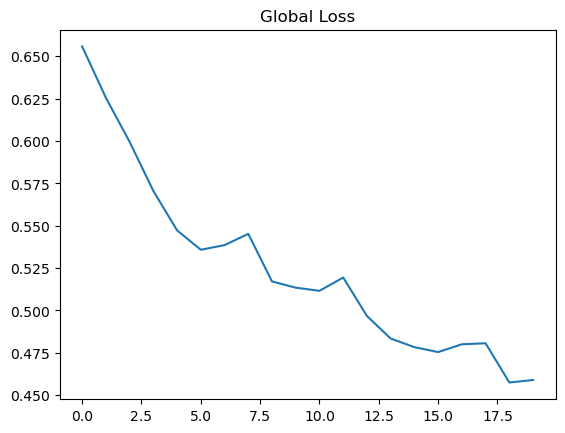

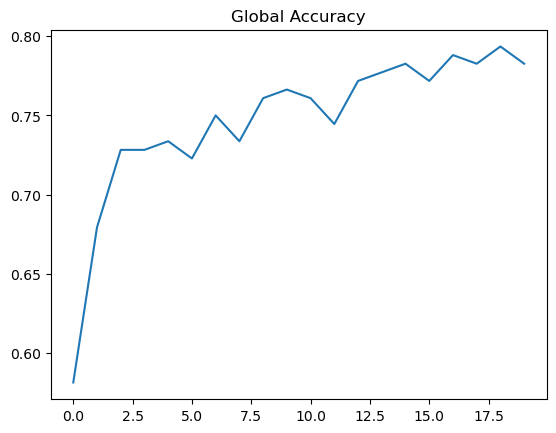

In [98]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build LSTM model
# -----------------------------
def build_lstm(input_shape, n_classes):
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_lstm(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for LSTM: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_lstm(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_lstm(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [104]:
Global_Loss_per_Round_LSTM = [0.6558166742324829, 0.6255497336387634, 0.5995301008224487, 0.5705536007881165, 0.5472714900970459, 0.5358011722564697, 0.5385496616363525, 0.545199990272522, 0.5171061754226685, 0.5134181976318359, 0.5115694999694824, 0.5193980932235718, 0.49673885107040405, 0.4833950698375702, 0.47830983996391296, 0.47540685534477234, 0.480001837015152, 0.4805903732776642, 0.4574538469314575, 0.4589133560657501]

Global_Accuracy_per_Round_LSTM = [0.58152174949646, 0.679347813129425, 0.72826087474823, 0.72826087474823, 0.7336956262588501, 0.7228260636329651, 0.75, 0.7336956262588501, 0.760869562625885, 0.7663043737411499, 0.760869562625885, 0.7445651888847351, 0.77173912525177, 0.7771739363670349, 0.782608687877655, 0.77173912525177, 0.7880434989929199, 0.782608687877655, 0.79347825050354, 0.782608687877655]

Round 1: Loss=0.6518, Accuracy=0.6630
Round 2: Loss=0.6298, Accuracy=0.6848
Round 3: Loss=0.6084, Accuracy=0.7228
Round 4: Loss=0.5765, Accuracy=0.7391
Round 5: Loss=0.5670, Accuracy=0.7337
Round 6: Loss=0.5318, Accuracy=0.7717
Round 7: Loss=0.5175, Accuracy=0.7717
Round 8: Loss=0.5393, Accuracy=0.7337
Round 9: Loss=0.5125, Accuracy=0.7663
Round 10: Loss=0.5139, Accuracy=0.7663
Round 11: Loss=0.5199, Accuracy=0.7554
Round 12: Loss=0.5333, Accuracy=0.7337
Round 13: Loss=0.5053, Accuracy=0.7935
Round 14: Loss=0.5142, Accuracy=0.7554
Round 15: Loss=0.4999, Accuracy=0.7772
Round 16: Loss=0.5010, Accuracy=0.7880
Round 17: Loss=0.4975, Accuracy=0.7717
Round 18: Loss=0.5021, Accuracy=0.7717
Round 19: Loss=0.4912, Accuracy=0.7717
Round 20: Loss=0.4858, Accuracy=0.7717

Global Loss per Round:
[0.6517558097839355, 0.6298360228538513, 0.6083500385284424, 0.5765294432640076, 0.5669708251953125, 0.5318441390991211, 0.5175395607948303, 0.539294958114624, 0.512487530708313, 0.5138669013977051, 0.5198

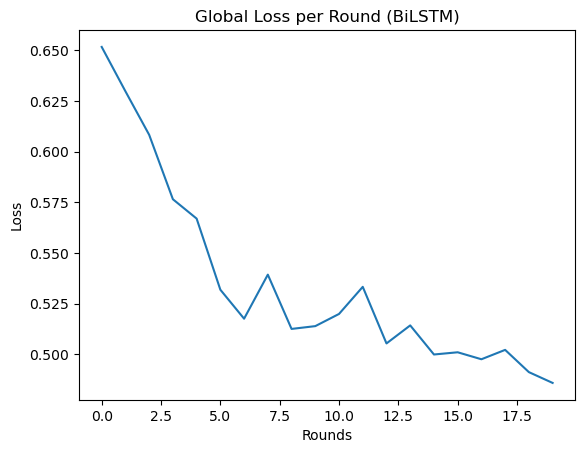

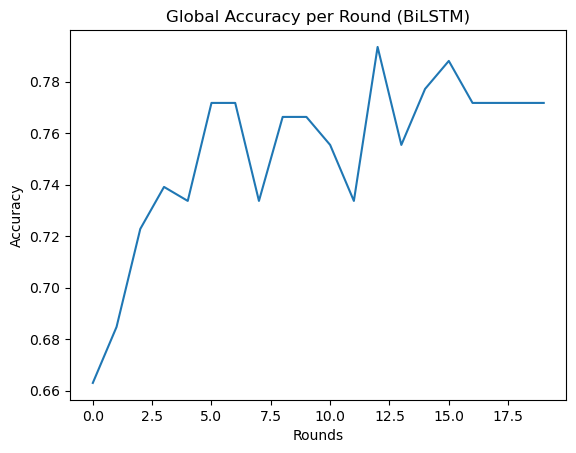

In [105]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build BiLSTM model
# -----------------------------
def build_bilstm(input_shape, n_classes):
    model = Sequential([
        Bidirectional(LSTM(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [
        sum(w * s for w, s in zip(ws, sizes)) / total
        for ws in zip(*[m.get_weights() for m in local_models])
    ]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics (BiLSTM)
# -----------------------------
def model_fedavg_bilstm(xtrain, ytrain, xtest, ytest,
                        n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy")  else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy")  else np.array(ytest)

    # Reshape for LSTM
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0],  xtest.shape[1],  1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_bilstm(xtrain.shape[1:], len(np.unique(ytrain)))

    global_loss = []
    global_acc = []

    for r in range(rounds):
        local_models, sizes = [], []

        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(
                optimizer=Adam(0.001),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))

        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)

        global_loss.append(loss)
        global_acc.append(acc)

        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    # ✅ PRINT LISTS
    print("\nGlobal Loss per Round:")
    print(global_loss)

    print("\nGlobal Accuracy per Round:")
    print(global_acc)

    # Evaluation
    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))

    # Plots
    plt.figure()
    plt.plot(global_loss)
    plt.title("Global Loss per Round (BiLSTM)")
    plt.xlabel("Rounds")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(global_acc)
    plt.title("Global Accuracy per Round (BiLSTM)")
    plt.xlabel("Rounds")
    plt.ylabel("Accuracy")
    plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_bilstm(
    xtrain, ytrain, xtest, ytest,
    n_clients=4, rounds=20, epochs=2
)


In [107]:
Global_Loss_per_Round_BiLSTM = [0.6517558097839355, 0.6298360228538513, 0.6083500385284424, 0.5765294432640076, 0.5669708251953125, 0.5318441390991211, 0.5175395607948303, 0.539294958114624, 0.512487530708313, 0.5138669013977051, 0.5198813080787659, 0.5332737565040588, 0.5053180456161499, 0.5142249464988708, 0.4998573660850525, 0.5009506344795227, 0.49750688672065735, 0.5021370053291321, 0.49115076661109924, 0.48581844568252563]


Global_Accuracy_per_Round_BiLSTM = [0.6630434989929199, 0.6847826242446899, 0.7228260636329651, 0.739130437374115, 0.7336956262588501, 0.77173912525177, 0.77173912525177, 0.7336956262588501, 0.7663043737411499, 0.7663043737411499, 0.7554348111152649, 0.7336956262588501, 0.79347825050354, 0.7554348111152649, 0.7771739363670349, 0.7880434989929199, 0.77173912525177, 0.77173912525177, 0.77173912525177, 0.77173912525177]

Round 1: Loss=0.6364, Accuracy=0.6141
Round 2: Loss=0.6172, Accuracy=0.6793
Round 3: Loss=0.5836, Accuracy=0.7011
Round 4: Loss=0.5635, Accuracy=0.7011
Round 5: Loss=0.5427, Accuracy=0.7174
Round 6: Loss=0.5228, Accuracy=0.7500
Round 7: Loss=0.5117, Accuracy=0.7663
Round 8: Loss=0.5031, Accuracy=0.7663
Round 9: Loss=0.4732, Accuracy=0.7935
Round 10: Loss=0.4891, Accuracy=0.7663
Round 11: Loss=0.4815, Accuracy=0.7717
Round 12: Loss=0.4624, Accuracy=0.7772
Round 13: Loss=0.4582, Accuracy=0.7717
Round 14: Loss=0.4576, Accuracy=0.7826
Round 15: Loss=0.4433, Accuracy=0.7772
Round 16: Loss=0.4402, Accuracy=0.7772
Round 17: Loss=0.4243, Accuracy=0.8043
Round 18: Loss=0.4237, Accuracy=0.8043
Round 19: Loss=0.4318, Accuracy=0.7935
Round 20: Loss=0.4357, Accuracy=0.7935

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.88      0.78        77
           1       0.90      0.73      0.80       107

    accuracy                           0

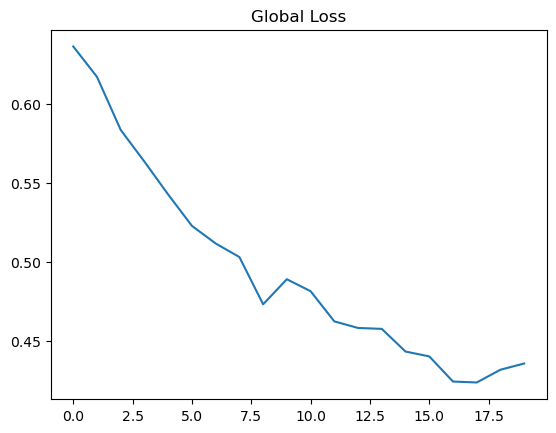

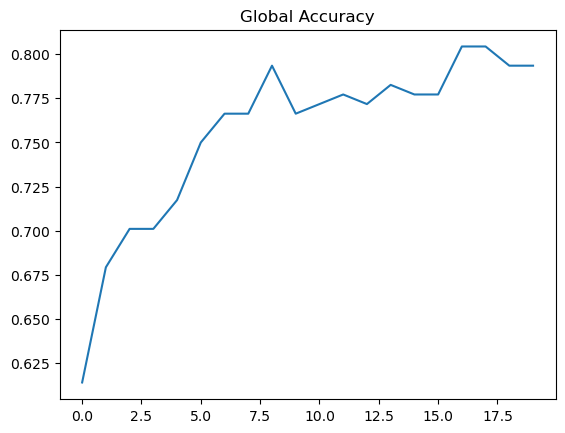

In [100]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build GRU model
# -----------------------------
def build_gru(input_shape, n_classes):
    model = Sequential([
        GRU(64, input_shape=input_shape, return_sequences=False),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_gru(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_gru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_gru(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [106]:
Global_Loss_per_Round_GRU = [0.6364140510559082, 0.6171720623970032, 0.5835548043251038, 0.5634746551513672, 0.5426753759384155, 0.522835910320282, 0.5116947293281555, 0.5030969977378845, 0.47318872809410095, 0.48905158042907715, 0.4814819395542145, 0.4623742997646332, 0.45819932222366333, 0.4576219618320465, 0.4432699382305145, 0.4402078092098236, 0.4242806136608124, 0.42368626594543457, 0.43176037073135376, 0.4356994330883026]


Global_Accuracy_per_Round_GRU = [0.614130437374115, 0.679347813129425, 0.7010869383811951, 0.7010869383811951, 0.717391312122345, 0.75, 0.7663043737411499, 0.7663043737411499, 0.79347825050354, 0.7663043737411499, 0.77173912525177, 0.7771739363670349, 0.77173912525177, 0.782608687877655, 0.7771739363670349, 0.7771739363670349, 0.804347813129425, 0.804347813129425, 0.79347825050354, 0.79347825050354]

Round 1: Loss=0.6225, Accuracy=0.7174
Round 2: Loss=0.5845, Accuracy=0.7391
Round 3: Loss=0.5550, Accuracy=0.7663
Round 4: Loss=0.5490, Accuracy=0.7554
Round 5: Loss=0.5256, Accuracy=0.7663
Round 6: Loss=0.5212, Accuracy=0.7663
Round 7: Loss=0.5115, Accuracy=0.7663
Round 8: Loss=0.4995, Accuracy=0.7880
Round 9: Loss=0.4934, Accuracy=0.7826
Round 10: Loss=0.4768, Accuracy=0.7989
Round 11: Loss=0.4752, Accuracy=0.7826
Round 12: Loss=0.4650, Accuracy=0.7826
Round 13: Loss=0.4411, Accuracy=0.7989
Round 14: Loss=0.4693, Accuracy=0.7826
Round 15: Loss=0.4541, Accuracy=0.7772
Round 16: Loss=0.4203, Accuracy=0.8315
Round 17: Loss=0.4171, Accuracy=0.8098
Round 18: Loss=0.4138, Accuracy=0.8152
Round 19: Loss=0.4165, Accuracy=0.8152
Round 20: Loss=0.4502, Accuracy=0.7989

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.91      0.79        77
           1       0.92      0.72      0.81       107

    accuracy                           0

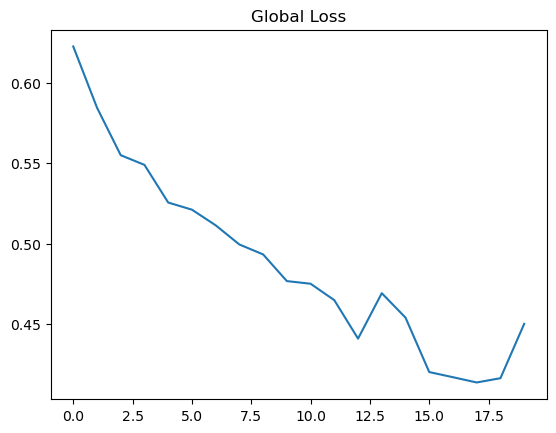

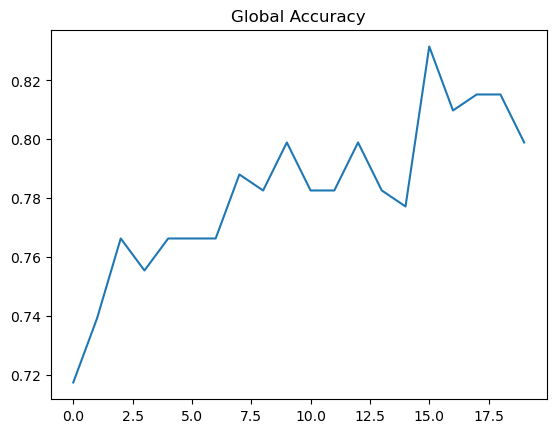

In [101]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import GRU, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Split data into clients
# -----------------------------
def split_clients(X, y, n_clients=5):
    idx = np.arange(len(X)); np.random.shuffle(idx)
    return [(X[s], y[s]) for s in np.array_split(idx, n_clients)]

# -----------------------------
# 2. Build BiGRU model
# -----------------------------
def build_bigru(input_shape, n_classes):
    model = Sequential([
        Bidirectional(GRU(64, return_sequences=False), input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# -----------------------------
# 3. FedAvg aggregation
# -----------------------------
def fedavg(global_model, local_models, sizes):
    total = np.sum(sizes)
    new_weights = [sum(w*s for w, s in zip(ws, sizes)) / total
                   for ws in zip(*[m.get_weights() for m in local_models])]
    global_model.set_weights(new_weights)
    return global_model

# -----------------------------
# 4. FedAvg training + metrics
# -----------------------------
def model_fedavg_bigru(xtrain, ytrain, xtest, ytest, n_clients=5, rounds=5, epochs=1):

    # Convert to NumPy arrays if needed
    xtrain = xtrain.to_numpy() if hasattr(xtrain, "to_numpy") else np.array(xtrain)
    xtest  = xtest.to_numpy()  if hasattr(xtest, "to_numpy") else np.array(xtest)
    ytrain = ytrain.to_numpy() if hasattr(ytrain, "to_numpy") else np.array(ytrain)
    ytest  = ytest.to_numpy()  if hasattr(ytest, "to_numpy") else np.array(ytest)

    # Reshape to 3D for GRU: (samples, timesteps, features)
    xtrain = xtrain.reshape(xtrain.shape[0], xtrain.shape[1], 1)
    xtest  = xtest.reshape(xtest.shape[0], xtest.shape[1], 1)

    clients = split_clients(xtrain, ytrain, n_clients)
    global_model = build_bigru(xtrain.shape[1:], len(np.unique(ytrain)))
    global_loss, global_acc = [], []

    for r in range(rounds):
        local_models, sizes = [], []
        for Xc, yc in clients:
            lm = clone_model(global_model)
            lm.set_weights(global_model.get_weights())
            lm.compile(Adam(0.001), 'sparse_categorical_crossentropy', ['accuracy'])
            lm.fit(Xc, yc, epochs=epochs, batch_size=32, verbose=0)
            local_models.append(lm)
            sizes.append(len(Xc))
        global_model = fedavg(global_model, local_models, sizes)
        loss, acc = global_model.evaluate(xtest, ytest, verbose=0)
        global_loss.append(loss); global_acc.append(acc)
        print(f"Round {r+1}: Loss={loss:.4f}, Accuracy={acc:.4f}")

    y_pred = np.argmax(global_model.predict(xtest, verbose=0), axis=1)
    print("\nClassification Report:\n", classification_report(ytest, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(ytest, y_pred))
    print("\nGlobal Loss per Round:", global_loss)
    print("Global Accuracy per Round:", global_acc)

    plt.figure(); plt.plot(global_loss); plt.title("Global Loss"); plt.show()
    plt.figure(); plt.plot(global_acc); plt.title("Global Accuracy"); plt.show()

    return global_model

# ------------------ CALL FUNCTION ------------------
global_model = model_fedavg_bigru(xtrain, ytrain, xtest, ytest, n_clients=4, rounds=20, epochs=2)


In [108]:
Global_Loss_per_Round_BiGRU = [0.6225314140319824, 0.5845460891723633, 0.55501389503479, 0.5489919781684875, 0.5256112217903137, 0.5211722254753113, 0.5114721655845642, 0.49954745173454285, 0.49338531494140625, 0.47681403160095215, 0.4751746952533722, 0.4649736285209656, 0.4410872161388397, 0.4693053662776947, 0.45412972569465637, 0.42031553387641907, 0.4171157777309418, 0.413848340511322, 0.4165160655975342, 0.4502485394477844]

Global_Accuracy_per_Round_BiGRU = [0.717391312122345, 0.739130437374115, 0.7663043737411499, 0.7554348111152649, 0.7663043737411499, 0.7663043737411499, 0.7663043737411499, 0.7880434989929199, 0.782608687877655, 0.7989130616188049, 0.782608687877655, 0.782608687877655, 0.7989130616188049, 0.782608687877655, 0.7771739363670349, 0.83152174949646, 0.8097826242446899, 0.8152173757553101, 0.8152173757553101, 0.7989130616188049]

In [114]:
df.shape

(918, 12)

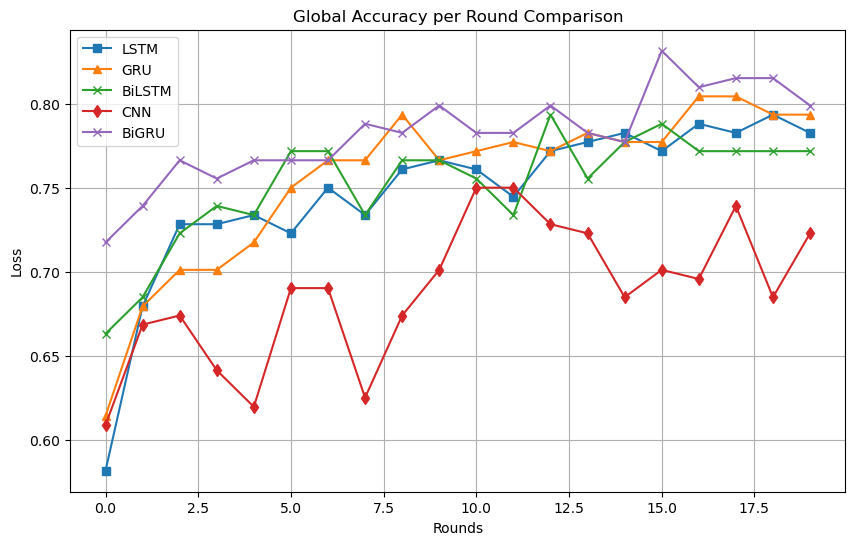

In [112]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(Global_Accuracy_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Accuracy_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Accuracy_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_accuracy_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Accuracy_per_Round_BiGRU, marker='x', label='BiGRU')

plt.title("Global Accuracy per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


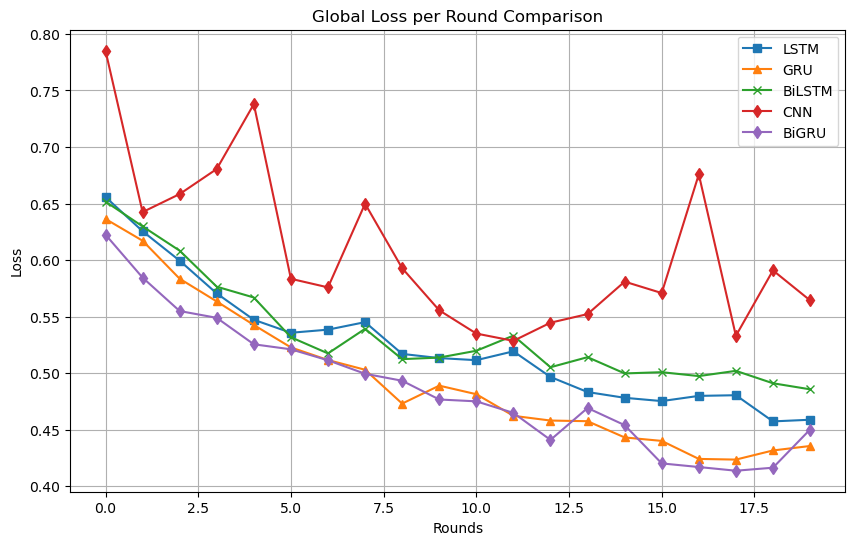

In [111]:
import matplotlib.pyplot as plt

# Plot all in one figure
plt.figure(figsize=(10,6))
plt.plot(Global_Loss_per_Round_LSTM, marker='s', label='LSTM')
plt.plot(Global_Loss_per_Round_GRU, marker='^', label='GRU')
plt.plot(Global_Loss_per_Round_BiLSTM, marker='x', label='BiLSTM')
plt.plot(global_loss_per_round_CNN, marker='d', label='CNN')
plt.plot(Global_Loss_per_Round_BiGRU, marker='d', label='BiGRU')

plt.title("Global Loss per Round Comparison")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
